# DV-SSM vs MV-SSM

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve
import scienceplots
plt.style.use('science')
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# 绘图设置
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 物理常数与参数
# ==========================================
C0 = {
    '11': 41.3e9, '12': 14.7e9, '13': 10.1e9,
    '22': 41.3e9, '23': 10.1e9, '33': 36.2e9,
    '44': 10.0e9, '55': 10.0e9, '66': 15.3e9
}
def get_C0_values():
    return (C0['11'], C0['12'], C0['13'], C0['22'], C0['23'], 
            C0['33'], C0['44'], C0['55'], C0['66'])

a = 1.0; b = 1.0; h = 0.1
xi = np.pi / a; eta = np.pi / b
q0 = -1.0e6

# ==========================================
# 2. 位移变量状态空间法 (修正版)
# ==========================================
def solve_displacement_method(lam):
    c11, c12, c13, c22, c23, c33, c44, c55, c66 = get_C0_values()
    grad_factor = lam / h

    M = np.zeros((6, 6))
    M[0, 3] = 1.0; M[1, 4] = 1.0; M[2, 5] = 1.0

    # Row 3 (U''): c55*U'' = ... - (c13+c55)*w',x
    # w',x = xi * W' * cos.  U'' * cos.
    # So U'' ~ - xi * W'
    # [Corrected Sign]: Negative
    M[3, 0] = (c11 * xi**2 + c66 * eta**2) / c55
    M[3, 1] = (c12 + c66) * xi * eta / c55
    M[3, 2] = -grad_factor * xi             # <--- FIXED (Was Positive)
    M[3, 3] = -grad_factor
    M[3, 5] = - (c13 + c55) * xi / c55      # <--- FIXED (Was Positive)

    # Row 4 (V''): Similar logic
    # [Corrected Sign]: Negative
    M[4, 0] = (c12 + c66) * xi * eta / c44
    M[4, 1] = (c66 * xi**2 + c22 * eta**2) / c44
    M[4, 2] = -grad_factor * eta            # <--- FIXED (Was Positive)
    M[4, 4] = -grad_factor
    M[4, 5] = - (c23 + c44) * eta / c44     # <--- FIXED (Was Positive)

    # Row 5 (W''): c33*W'' + ... + c13*u',x + c55(u',x + ...) = 0
    # u',x = -xi * U'. 
    # Term is (c13+c55) * (-xi U'). Moved to RHS becomes +
    # Sign is Positive. (This was actually correct in previous version)
    M[5, 0] = grad_factor * c13 * xi / c33 
    M[5, 1] = grad_factor * c23 * eta / c33
    M[5, 2] = (c55 * xi**2 + c44 * eta**2) / c33
    M[5, 3] = (c13 + c55) * xi / c33        
    M[5, 4] = (c23 + c44) * eta / c33
    M[5, 5] = -grad_factor

    # Boundary Q Matrix
    def get_Q_matrix(z_val):
        factor = np.exp(lam * z_val / h)
        _c55 = c55 * factor; _c44 = c44 * factor
        _c13 = c13 * factor; _c23 = c23 * factor; _c33 = c33 * factor
        Q = np.zeros((3, 6))
        # tau_zx = c55(U' + xi*W)
        Q[0, 2] = _c55 * xi; Q[0, 3] = _c55
        # tau_zy = c44(V' + eta*W)
        Q[1, 2] = _c44 * eta; Q[1, 4] = _c44
        # sigma_z = c13(-xi U) + ... + c33 W'
        Q[2, 0] = -_c13 * xi; Q[2, 1] = -_c23 * eta; Q[2, 5] = _c33
        return Q

    Q0 = get_Q_matrix(0); Qh = get_Q_matrix(h)
    T = expm(M * h)
    A_sys = np.vstack([Q0, Qh @ T])
    B_sys = np.zeros(6); B_sys[5] = q0
    delta0 = solve(A_sys, B_sys)

    z_vals = np.linspace(0, h, 51)
    res = {'z': z_vals, 'w': [], 'sig_x': [], 'tau_xz': []}
    for z in z_vals:
        dz = expm(M * z) @ delta0
        U, V, W, Up, Vp, Wp = dz
        factor = np.exp(lam * z / h)
        res['w'].append(W)
        # Sigma_x check: u,x = -xi U
        res['sig_x'].append(factor * (c11 * (-xi * U) + c12 * (-eta * V) + c13 * Wp))
        res['tau_xz'].append(factor * c55 * (Up + xi * W))
    return res

# ==========================================
# 3. 混合变量状态空间法 (修正版)
# ==========================================
def solve_mixed_method(lam):
    c11, c12, c13, c22, c23, c33, c44, c55, c66 = get_C0_values()
    alpha = lam / h
    M = np.zeros((6, 6))

    # Row 0 (U'): u,z = -w,x + ... => U' = -xi W + ...
    # [Corrected Sign]: Negative
    M[0, 2] = -xi;            M[0, 3] = 1.0 / c55  # <--- FIXED (Was Positive)

    # Row 1 (V'): v,z = -w,y + ... => V' = -eta W + ...
    # [Corrected Sign]: Negative
    M[1, 2] = -eta;           M[1, 4] = 1.0 / c44  # <--- FIXED (Was Positive)

    # Row 2 (W'): w,z = -c13/c33 u,x + ... => W' = -c13/c33 (-xi U) ... = +
    M[2, 0] = c13 * xi / c33; M[2, 1] = c23 * eta / c33; M[2, 5] = 1.0 / c33

    # Row 3 (X'): tau,z = -sigma_x,x ...
    # sigma_x = Q11 u,x + ... + c13/c33 sigma_z
    # sigma_x,x ~ -xi^2 U (-xi) -> No. u,x = -xi U. u,xx = -xi^2 U.
    # sigma_x,x = Q11 (-xi^2 U) + ... + c13/c33 (xi Z) 
    # Note: sigma_z ~ sin. sigma_z,x ~ xi cos. So term is + xi Z.
    # X' = - sigma_x,x = - ( ... + c13/c33 xi Z )
    # So Z coeff is Negative.
    Q11 = c11 - c13**2 / c33
    Q12 = c12 - c13 * c23 / c33
    M[3, 0] = Q11 * xi**2 + c66 * eta**2
    M[3, 1] = (Q12 + c66) * xi * eta
    M[3, 3] = -alpha
    M[3, 5] = - (c13 * xi / c33) 

    # Row 4 (Y')
    Q22 = c22 - c23**2 / c33
    M[4, 0] = (Q12 + c66) * xi * eta
    M[4, 1] = Q22 * eta**2 + c66 * xi**2
    M[4, 4] = -alpha
    M[4, 5] = - (c23 * eta / c33)

    # Row 5 (Z'): sigma_z,z = -tau_xz,x - ...
    # tau_xz ~ cos. tau_xz,x ~ -xi sin.
    # Z' ~ - ( -xi X ) = + xi X
    M[5, 3] = xi; M[5, 4] = eta; M[5, 5] = -alpha

    # Solve
    T = expm(M * h)
    target_stress_bar_h = np.array([0, 0, q0 * np.exp(-alpha * h)])
    T_stress_disp = T[3:6, 0:3]
    displ_0 = solve(T_stress_disp, target_stress_bar_h)
    Y0 = np.concatenate([displ_0, [0, 0, 0]])

    z_vals = np.linspace(0, h, 51)
    res = {'z': z_vals, 'w': [], 'sig_x': [], 'tau_xz': []}
    for z in z_vals:
        Yz = expm(M * z) @ Y0
        U, V, W, X_bar, Y_bar, Z_bar = Yz
        factor = np.exp(alpha * z)
        res['w'].append(W)
        res['tau_xz'].append(X_bar * factor)
        # Sig_x check: u,x = -xi U
        res['sig_x'].append(factor * (Q11 * (-xi * U) + Q12 * (-eta * V) + (c13 / c33) * Z_bar))
    return res


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690388\1876033859.py:7: SyntaxWarning: invalid escape sequence '\s'
  titles = ['(a) Deflection $w$', '(b) Normal Stress $\sigma_x$', '(c) Shear Stress $\\tau_{xz}$']
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690388\1876033859.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(res_disp[key], res_disp['z'], color=c, ls='-', lw=2, alpha=0.4, label=f'Disp $\lambda={lam}$')
C:\Users\AlbireoBai\AppData\Local\Temp\ipykernel_690388\1876033859.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(res_mix[key], res_mix['z'], color=c, ls=':', lw=2, marker='o', ms=3, markevery=15, label=f'Mixed $\lambda={lam}$')


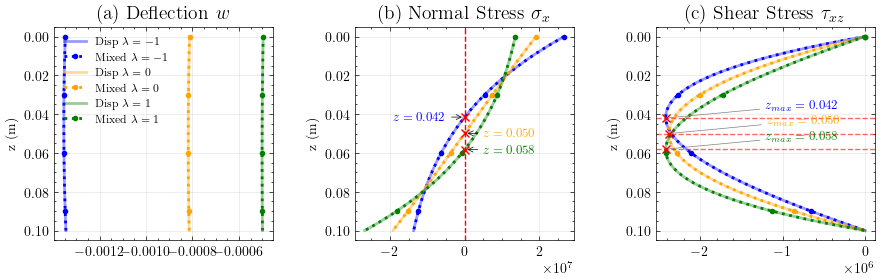

In [7]:
# ==========================================
# 4. 对比绘图 (已增加剪应力分布中心标注)
# ==========================================
lambdas = [-1, 0, 1]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
keys = ['w', 'sig_x', 'tau_xz']
titles = ['(a) Deflection $w$', '(b) Normal Stress $\sigma_x$', '(c) Shear Stress $\\tau_{xz}$']
colors = { -1: 'blue', 0: 'orange', 1: 'green' }

# 存储标记信息
intersections_sig = {} # 用于存储正应力零点
peaks_tau = {}         # 用于存储剪应力峰值点

for lam in lambdas:
    res_disp = solve_displacement_method(lam)
    res_mix = solve_mixed_method(lam)
    c = colors[lam]
    
    # 1. 计算 Sigma_x 的零点 (中性层)
    sig_x = np.array(res_disp['sig_x'])
    z = np.array(res_disp['z'])
    idx_sig = np.where(np.diff(np.signbit(sig_x)))[0]
    if len(idx_sig) > 0:
        i = idx_sig[0]
        z0 = z[i] + (0 - sig_x[i]) * (z[i+1] - z[i]) / (sig_x[i+1] - sig_x[i])
        intersections_sig[lam] = z0
        
    # 2. 计算 Tau_xz 的分布中心 (峰值位置)
    tau_xz = np.array(res_disp['tau_xz'])
    idx_peak = np.argmax(np.abs(tau_xz)) # 寻找幅值最大的索引
    z_peak = z[idx_peak]
    val_peak = tau_xz[idx_peak]
    peaks_tau[lam] = (z_peak, val_peak)

    for i, key in enumerate(keys):
        ax = axes[i]
        # 绘制位移法结果 (粗浅色实线)
        ax.plot(res_disp[key], res_disp['z'], color=c, ls='-', lw=2, alpha=0.4, label=f'Disp $\lambda={lam}$')
        # 绘制混合法结果 (虚线点)
        ax.plot(res_mix[key], res_mix['z'], color=c, ls=':', lw=2, marker='o', ms=3, markevery=15, label=f'Mixed $\lambda={lam}$')

# 格式化坐标轴
for i, ax in enumerate(axes):
    ax.invert_yaxis()
    ax.set_title(titles[i], fontsize=14)
    ax.set_ylabel('z (m)')
    ax.grid(True, alpha=0.3)
    if i == 0:
         ax.legend(loc='best', fontsize=8)

# ------------------------------------------------
# 图 (b) 正应力: 标注中性层
# ------------------------------------------------
ax_sig = axes[1]
ax_sig.axvline(x=0, color='red', linestyle='--', linewidth=1)
for lam, z0 in intersections_sig.items():
    c = colors[lam]
    ax_sig.plot(0, z0, marker='x', color='red', markersize=6)
    offset_x = 0.5e7 if lam != -1 else -0.5e7
    align = 'left' if lam != -1 else 'right'
    ax_sig.annotate(f'$z={z0:.3f}$', xy=(0, z0), xytext=(offset_x, z0),
                    arrowprops=dict(facecolor='black', arrowstyle='->', lw=0.5),
                    fontsize=9, color=c, verticalalignment='center', horizontalalignment=align)

# ------------------------------------------------
# 图 (c) 剪应力: 增加红色横线标注分布中心 (峰值)
# ------------------------------------------------
ax_tau = axes[2]
for lam, (z_p, val_p) in peaks_tau.items():
    c = colors[lam]
    # 绘制红色横线穿过分布中心
    ax_tau.axhline(y=z_p, color='red', linestyle='--', linewidth=1, alpha=0.6)
    # 在曲线交点处打上标记
    ax_tau.plot(val_p, z_p, marker='x', color='red', markersize=6)
    # 标注分布中心深度 z 的数值
    ax_tau.annotate(f'$z_{{max}}={z_p:.3f}$', xy=(val_p, z_p), xytext=(val_p*0.5, z_p - 0.005),
                    fontsize=9, color=c, fontweight='bold', arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.savefig('13-comparison_final_annotated.svg', format='svg', dpi=1000)
plt.show()